In [ ]:
!pip install qiskit qiskit-ibm-runtime qiskit-addon-sqd ffsim pyscf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.5/725.5 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.9/386.9 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.0/218.0 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 10.9 MB/s eta 0:00:00


In [ ]:
! pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=afa82335f36c574ee461fd1471d171be49acb6d464533d492550aaa000fd2fa2
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
import warnings
import pyscf
import pyscf.cc
import pyscf.mcscf

warnings.filterwarnings("ignore")

open_shell = False
spin_sq = 0

mol = pyscf.gto.Mole()
mol.build(
    atom=[["N", (0, 0, 0)], ["N", (1.0, 0, 0)]],  # Two N atoms 1 angstrom apart
    basis="6-31g",
    symmetry="Dooh",
)

n_frozen=2
active_space=range(n_frozen,mol.nao_nr())


scf = pyscf.scf.RHF(mol).run()

num_orbitals = len(active_space)
n_electrons = int(sum(scf.mo_occ[active_space]))
num_elec_a = (n_electrons + mol.spin) // 2
num_elec_b = (n_electrons - mol.spin) // 2

cas = pyscf.mcscf.CASCI(scf, num_orbitals, (num_elec_a, num_elec_b))
mo = cas.sort_mo(active_space, base=0)

hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)  # hcore: one-body integrals
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), num_orbitals)  # eri: two-body integrals

exact_energy = cas.run().e_tot


WARN: Unable to to identify input symmetry using original axes.
Different symmetry axes will be used.

converged SCF energy = -108.835236570774
CASCI E = -109.046671778080  E(CI) = -32.8155692383188  S^2 = 0.0000000


In [ ]:
ccsd = pyscf.cc.CCSD(
    scf, frozen=[i for i in range(mol.nao_nr()) if i not in active_space]
)
ccsd.run()

t1 = ccsd.t1
t2 = ccsd.t2


E(CCSD) = -109.0398256929733  E_corr = -0.2045891221988316


In [ ]:
import ffsim
from qiskit import QuantumCircuit, QuantumRegister

n_reps = 2
alpha_alpha_indices = [(p, p + 1) for p in range(num_orbitals - 1)]
alpha_beta_indices = [(p, p) for p in range(0, num_orbitals, 4)]

ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    t2=t2,
    t1=t1,
    n_reps=n_reps,
    interaction_pairs=(alpha_alpha_indices, alpha_beta_indices),
)

nelec = (num_elec_a, num_elec_b)

qubits = QuantumRegister(2 * num_orbitals, name="q")
circuit = QuantumCircuit(qubits)

circuit.append(ffsim.qiskit.PrepareHartreeFockJW(num_orbitals, nelec), qubits)

circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)
circuit.measure_all()

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="4onfpcb4KZOqUvqyj_wJjrxRBW2HOWufuFY_q4P5Qxsm",
    overwrite=True
)

print("✅ Authentication successful! Account credentials saved.")

✅ Authentication successful! Account credentials saved.


In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)
# backend = service.backend("ibm_brisbane")

qiskit_runtime_service.__init__:WARNING:2026-06-20 09:49:52,543: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-20 09:49:53,022: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-20 09:49:55,784: Using instance: open-instance, plan: open


In [ ]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

spin_a_layout = [0, 14, 18, 19, 20, 33, 39, 40, 41, 53, 60, 61, 62, 72, 81, 82]
spin_b_layout = [2, 3, 4, 15, 22, 23, 24, 34, 43, 44, 45, 54, 64, 65, 66, 73]

initial_layout = spin_a_layout + spin_b_layout

pass_manager = generate_preset_pass_manager(
    optimization_level=3, backend=backend, initial_layout=initial_layout
)

# without PRE_INIT passes
isa_circuit = pass_manager.run(circuit)
print(f"Gate counts (w/o pre-init passes): {isa_circuit.count_ops()}")

# with PRE_INIT passes
# We will use the circuit generated by this pass manager for hardware execution
pass_manager.pre_init = ffsim.qiskit.PRE_INIT
isa_circuit = pass_manager.run(circuit)
print(f"Gate counts (w/ pre-init passes): {isa_circuit.count_ops()}")

Gate counts (w/o pre-init passes): OrderedDict({'sx': 8629, 'rz': 6264, 'cz': 3598, 'x': 401, 'measure': 32, 'barrier': 1})
Gate counts (w/ pre-init passes): OrderedDict({'sx': 5708, 'rz': 3713, 'cz': 2599, 'x': 321, 'measure': 32, 'barrier': 1})


In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)
sampler.options.dynamical_decoupling.enable = True

job = sampler.run([isa_circuit], shots=10_000)  # Takes approximately 5sec of QPU time

In [ ]:
# Run cell after IQX job completion
primitive_result = job.result()
pub_result = primitive_result[0]
counts = pub_result.data.meas.get_counts()

In [ ]:
from qiskit_addon_sqd.counts import counts_to_arrays

# Convert counts into bitstring and probability arrays
bitstring_matrix_full, probs_arr_full = counts_to_arrays(counts)

In [ ]:
import numpy as np
from qiskit_addon_sqd.configuration_recovery import recover_configurations
from qiskit_addon_sqd.fermion import (
    bitstring_matrix_to_ci_strs,
    solve_fermion,
)
from qiskit_addon_sqd.subsampling import postselect_and_subsample

rng = np.random.default_rng(24)
# SQD options
iterations = 5

# Eigenstate solver options
n_batches = 5
samples_per_batch = 500
max_davidson_cycles = 300

# Self-consistent configuration recovery loop
e_hist = np.zeros((iterations, n_batches))  # energy history
s_hist = np.zeros((iterations, n_batches))  # spin history
occupancy_hist = []
avg_occupancy = None
for i in range(iterations):
    print(f"Starting configuration recovery iteration {i}")
    # On the first iteration, we have no orbital occupancy information from the
    # solver, so we begin with the full set of noisy configurations.
    if avg_occupancy is None:
        bs_mat_tmp = bitstring_matrix_full
        probs_arr_tmp = probs_arr_full

    # If we have average orbital occupancy information, we use it to refine
    # the full set of noisy configurations.
    else:
        bs_mat_tmp, probs_arr_tmp = recover_configurations(
            bitstring_matrix_full,
            probs_arr_full,
            avg_occupancy,
            num_elec_a,
            num_elec_b,
            rand_seed=rng,
        )

    # Create batches of subsamples. We postselect here to remove configurations
    # with incorrect hamming weight during iteration 0, since no config recovery was performed.
    batches = postselect_and_subsample(
        bs_mat_tmp,
        probs_arr_tmp,
        hamming_right=num_elec_a,
        hamming_left=num_elec_b,
        samples_per_batch=samples_per_batch,
        num_batches=n_batches,
        rand_seed=rng,
    )

    # Run eigenstate solvers in a loop. This loop should be parallelized for larger problems.
    e_tmp = np.zeros(n_batches)
    s_tmp = np.zeros(n_batches)
    occs_tmp = []
    coeffs = []
    for j in range(n_batches):
        strs_a, strs_b = bitstring_matrix_to_ci_strs(batches[j])
        print(f"  Batch {j} subspace dimension: {len(strs_a) * len(strs_b)}")
        energy_sci, coeffs_sci, avg_occs, spin = solve_fermion(
            batches[j],
            hcore,
            eri,
            open_shell=open_shell,
            spin_sq=spin_sq,
            max_cycle=max_davidson_cycles,  #  CHANGED to max_cycle
        )
        energy_sci += nuclear_repulsion_energy
        e_tmp[j] = energy_sci
        s_tmp[j] = spin
        occs_tmp.append(avg_occs)
        coeffs.append(coeffs_sci)

    # Combine batch results
    avg_occupancy = tuple(np.mean(occs_tmp, axis=0))

    # Track optimization history
    e_hist[i, :] = e_tmp
    s_hist[i, :] = s_tmp
    occupancy_hist.append(avg_occupancy)

Starting configuration recovery iteration 0
  Batch 0 subspace dimension: 7056
  Batch 1 subspace dimension: 7056
  Batch 2 subspace dimension: 7056
  Batch 3 subspace dimension: 7056
  Batch 4 subspace dimension: 7056
Starting configuration recovery iteration 1
  Batch 0 subspace dimension: 538756
  Batch 1 subspace dimension: 509796
  Batch 2 subspace dimension: 546121
  Batch 3 subspace dimension: 511225
  Batch 4 subspace dimension: 532900
Starting configuration recovery iteration 2
  Batch 0 subspace dimension: 463761
  Batch 1 subspace dimension: 467856
  Batch 2 subspace dimension: 515524
  Batch 3 subspace dimension: 474721
  Batch 4 subspace dimension: 487204
Starting configuration recovery iteration 3
  Batch 0 subspace dimension: 521284
  Batch 1 subspace dimension: 524176
  Batch 2 subspace dimension: 512656
  Batch 3 subspace dimension: 521284
  Batch 4 subspace dimension: 534361
Starting configuration recovery iteration 4
  Batch 0 subspace dimension: 522729
  Batch 1 sub

In [ ]:
# Data for energies plot
x1 = range(iterations)
min_e = [np.min(e) for e in e_hist]
e_diff = [abs(e - exact_energy) for e in min_e]
yt1 = [1.0, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5]

# Chemical accuracy (+/- 1 milli-Hartree)
chem_accuracy = 0.001

# Data for avg spatial orbital occupancy
y2 = occupancy_hist[-1][0] + occupancy_hist[-1][1]
x2 = range(len(y2))

Exact energy: -109.04667 Ha
SQD energy: -109.02376 Ha
Absolute error: 0.02291 Ha


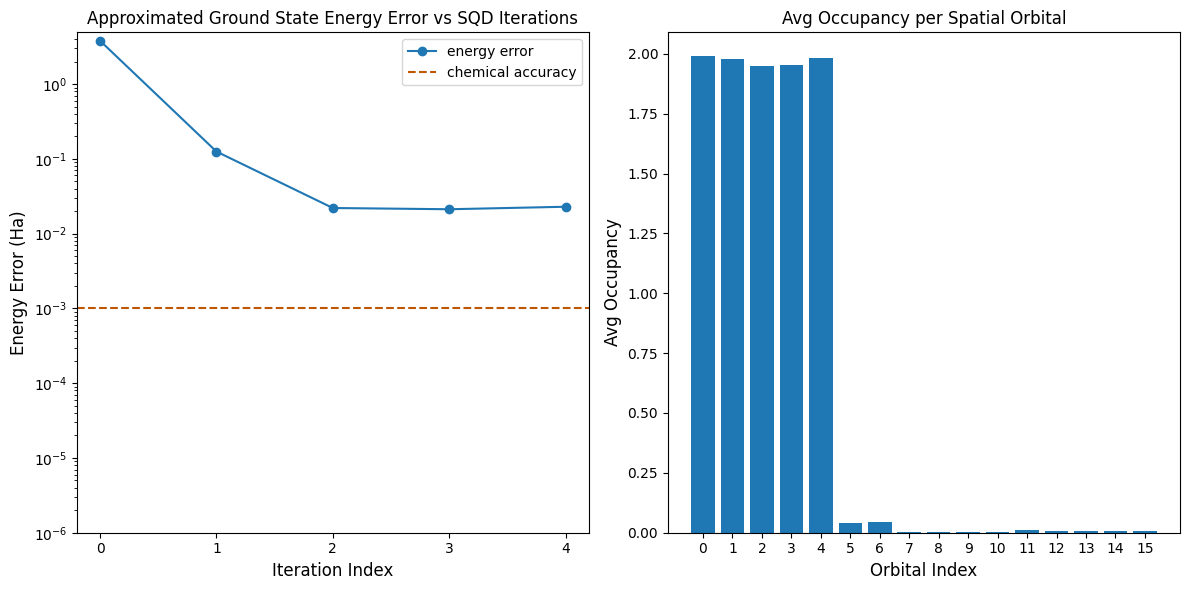

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot energies
axs[0].plot(x1, e_diff, label="energy error", marker="o")
axs[0].set_xticks(x1)
axs[0].set_xticklabels(x1)
axs[0].set_yticks(yt1)
axs[0].set_yticklabels(yt1)
axs[0].set_yscale("log")
axs[0].set_ylim(1e-6)
axs[0].axhline(
    y=chem_accuracy, color="#BF5700", linestyle="--", label="chemical accuracy"
)
axs[0].set_title("Approximated Ground State Energy Error vs SQD Iterations")
axs[0].set_xlabel("Iteration Index", fontdict={"fontsize": 12})
axs[0].set_ylabel("Energy Error (Ha)", fontdict={"fontsize": 12})
axs[0].legend()

# Plot orbital occupancy
axs[1].bar(x2, y2, width=0.8)
axs[1].set_xticks(x2)
axs[1].set_xticklabels(x2)
axs[1].set_title("Avg Occupancy per Spatial Orbital")
axs[1].set_xlabel("Orbital Index", fontdict={"fontsize": 12})
axs[1].set_ylabel("Avg Occupancy", fontdict={"fontsize": 12})

print(f"Exact energy: {exact_energy:.5f} Ha")
print(f"SQD energy: {min_e[-1]:.5f} Ha")
print(f"Absolute error: {e_diff[-1]:.5f} Ha")
plt.tight_layout()
plt.show()

skqd

$$
H = \sum_{i,j}^{N} J_{xy}\left(X_i X_j + Y_i Y_j\right) + Z_i Z_j
$$

In [ ]:
!pip install qiskit-addon-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 2.8 MB/s eta 0:00:00


In [ ]:
from qiskit.transpiler import CouplingMap
from qiskit_addon_utils.problem_generators import generate_xyz_hamiltonian

num_spins = 22
coupling_map = CouplingMap.from_ring(num_spins)
H_op = generate_xyz_hamiltonian(coupling_map, coupling_constants=(0.3, 0.3, 1.0))

In [ ]:
# Set parameters for quantum Krylov algorithm
krylov_dim = 5  # size of krylov subspace
dt = 0.15
num_trotter_steps = 6

In [ ]:
# Set parameters for quantum Krylov algorithm
krylov_dim = 5  # size of krylov subspace
dt = 0.15
num_trotter_steps = 6

# Prep `Neel` state as the reference state for evolution
from qiskit import QuantumCircuit

qc_state_prep = QuantumCircuit(num_spins)
for i in range(num_spins):
    if i % 2 == 0:
        qc_state_prep.x(i)

In [ ]:
from qiskit.circuit import QuantumRegister
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter

evol_gate = PauliEvolutionGate(
    H_op, time=(dt / num_trotter_steps), synthesis=LieTrotter(reps=num_trotter_steps)
)  # `U` operator

qr = QuantumRegister(num_spins)
qc_evol = QuantumCircuit(qr)
qc_evol.append(evol_gate, qargs=qr)

circuits = []
for rep in range(krylov_dim):
    circ = qc_state_prep.copy()

    # Repeating the `U` operator to implement U^0, U^1, U^2, and so on, for power Krylov space
    for _ in range(rep):
        circ.compose(other=qc_evol, inplace=True)

    circ.measure_all()
    circuits.append(circ)

In [ ]:
!pip install pylatexenc

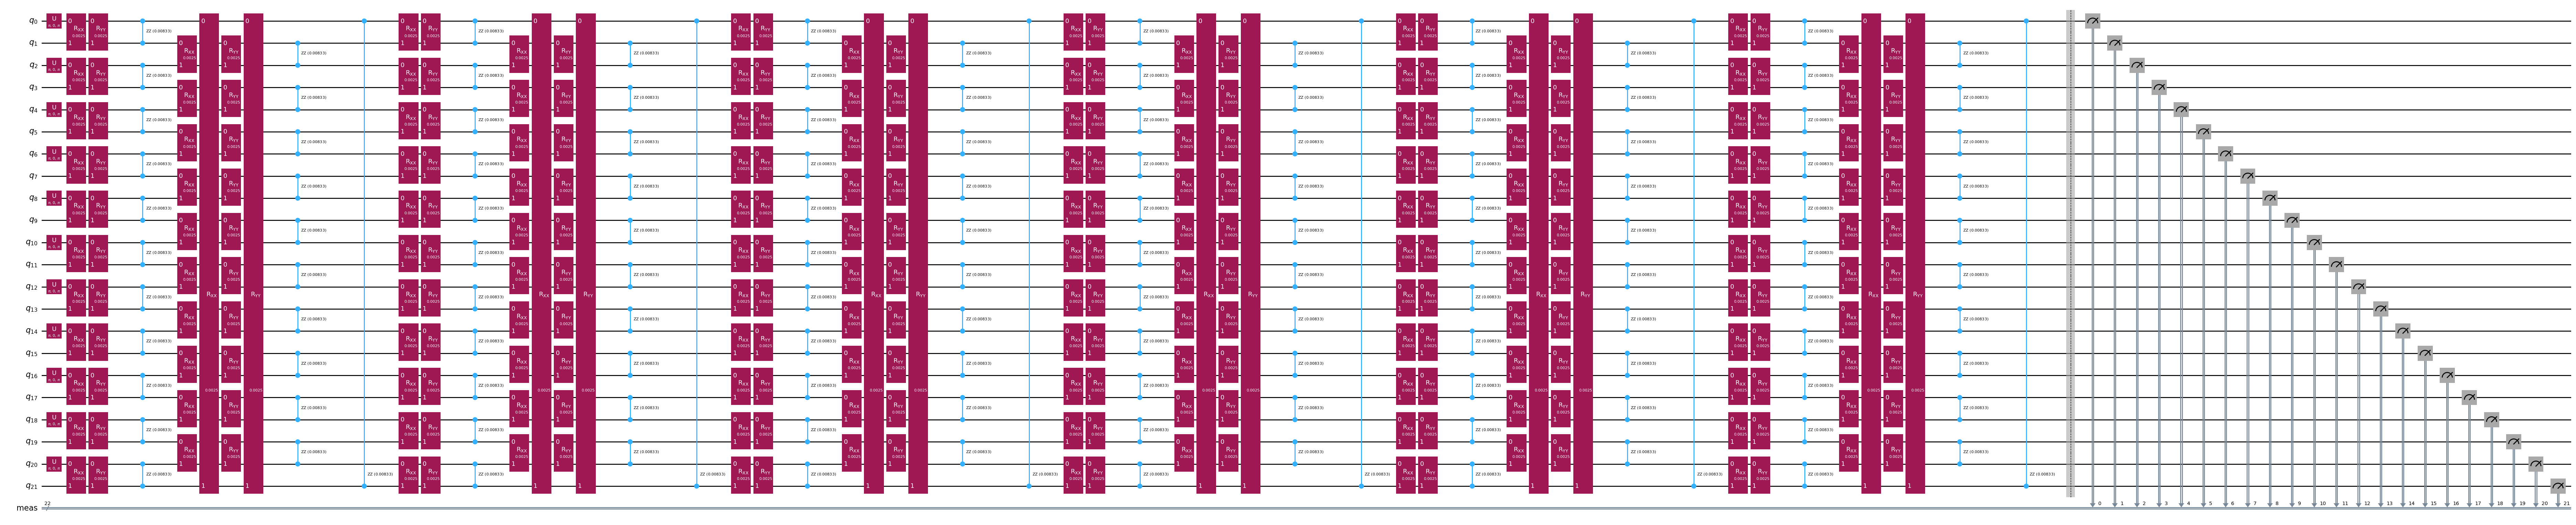

In [ ]:
circuits[1].decompose().draw('mpl', fold=-1)

In [ ]:
import warnings

from qiskit import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

warnings.filterwarnings("ignore")

service = QiskitRuntimeService()
# Use the least-busy backend or specify a quantum computer using the syntax commented out below.
backend = service.least_busy(operational=True, simulator=False)
# backend = service.backend("ibm_brisbane")

qiskit_runtime_service.__init__:WARNING:2026-06-20 10:09:38,576: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-20 10:09:38,824: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-20 10:09:42,051: Using instance: open-instance, plan: open


In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)
job = sampler.run(isa_circuits, shots=100_000)  # Takes approximately 2m 58s of QPU time

NameError: name 'isa_circuits' is not defined

In [ ]:
counts_all = [job.result()[k].data.meas.get_counts() for k in range(krylov_dim)]

In [ ]:
from collections import Counter

counts_cumulative = []
for i in range(krylov_dim):
    counter = Counter()
    for d in counts_all[: i + 1]:
        counter.update(d)

    counts = dict(counter)
    counts_cumulative.append(counts)

In [ ]:
from qiskit_addon_sqd.counts import counts_to_arrays
from qiskit_addon_sqd.qubit import solve_qubit

In [ ]:
# Filters out bitstrings that do not have specified number (`num_ones`) of `1` bits.
def postselect_counts(counts, num_ones):
    filtered_counts = {}
    for bitstring, freq in counts.items():
        if bitstring.count("1") == num_ones:
            filtered_counts[bitstring] = freq

    return filtered_counts

In [ ]:
import numpy as np

num_batches = 10
rand_seed = 0
scipy_kwargs = {"k": 2, "which": "SA"}

ground_state_energies = []
for idx, counts in enumerate(counts_cumulative):
    counts = postselect_counts(counts, num_ones=num_spins // 2)
    bitstring_matrix, probs = counts_to_arrays(counts=counts)

    eigenvals, eigenstates = solve_qubit(
        bitstring_matrix, H_op, verbose=False, **scipy_kwargs
    )
    gs_en = np.min(eigenvals)
    ground_state_energies.append(gs_en)

NameError: name 'counts_cumulative' is not defined

In [ ]:
import matplotlib.pyplot as plt

exact_gs_en = -23.934184
plt.plot(
    range(1, krylov_dim + 1),
    ground_state_energies,
    color="blue",
    linestyle="-.",
    label="estimate",
)
plt.plot(
    range(1, krylov_dim + 1),
    [exact_gs_en] * krylov_dim,
    color="red",
    linestyle="-",
    label="exact",
)
plt.xticks(range(1, krylov_dim + 1), range(1, krylov_dim + 1))
plt.legend()
plt.xlabel("Krylov space dimension")
plt.ylabel("Energy")
plt.ylim([-24, -22.50])
plt.title(
    "Estimating Ground state energy with Sample-based Krylov Quantum Diagonalization"
)
plt.show()

vqe in h2 using the ibm hardware

In [ ]:
# !pip install qiskit-nature qiskit_aer qiskit_algorithms qiskit_ibm_runtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 26.0 MB/s eta 0:00:00


In [ ]:
# from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2
# from qiskit_algorithms.minimum_eigensolvers import VQE
# from qiskit_algorithms.optimizers import COBYLA

# from qiskit_nature.second_q.drivers import PySCFDriver
# # from qiskit_nature.second_q.mappers import JordanWignerMapper
# from qiskit_nature.second_q.circuit.library import UCCSD
# from qiskit_nature.second_q.algorithms.initial_points import HFInitialPoint

# from qiskit_nature.second_q.circuit.library import HartreeFock

In [ ]:
# driver = PySCFDriver(
#     atom="H 0 0 0; H 0 0 0.735",
#     basis="sto3g"
# )

# problem = driver.run()

# mapper = JordanWignerMapper()

# hamiltonian = mapper.map(problem.hamiltonian.second_q_op())

# num_particles = problem.num_particles
# num_spatial_orbitals = problem.num_spatial_orbitals


In [ ]:
# ansatz = UCCSD(
#     num_spatial_orbitals=num_spatial_orbitals,
#     num_particles=num_particles,
#     qubit_mapper=mapper,
#     initial_state=HartreeFock(
#         num_spatial_orbitals,
#         num_particles,
#         mapper
#     )
# )

# initial_point = HFInitialPoint()
# initial_point.ansatz = ansatz
# initial_point.problem = problem

In [ ]:
# from qiskit import transpile

# ansatz = transpile(
#     ansatz,
#     backend=backend,
#     optimization_level=1
# )

In [ ]:
# service=QiskitRuntimeService()
# backend=service.least_busy(operational=True, simulator=False)
# print("Backend:", backend.name)

qiskit_runtime_service.__init__:WARNING:2026-06-20 10:13:49,495: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-20 10:13:49,857: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-20 10:13:52,282: Using instance: open-instance, plan: open


Backend: ibm_fez


In [ ]:
# exact_energy=np.linalg.eigh(hamiltonian.to_matrix())[0][0]
# print("Exact energy:", exact_energy)

Exact energy: -1.8572750302023797


In [ ]:
# optimizer = COBYLA(maxiter=10)
# estimator = EstimatorV2(mode=backend)

# counts=[]
# values=[]
# def callback_function(eval_count, parameters, mean, std):
#     counts.append(eval_count)
#     values.append(mean)


# vqe = VQE(
#     estimator,
#     ansatz,
#     optimizer,
#     initial_point=initial_point.to_numpy_array(),
#     callback=callback_function
# )

In [ ]:
# vqe_energy=vqe.compute_minimum_eigenvalue(hamiltonian).eigenvalue.real
# print("VQE energy:", vqe_energy)

VQE energy: -0.9224469689958208


In [ ]:
# plt.figure(gigsize=(14,8))
# plt.plot(counts,values,linestyle='-',color='blue',label='vqe energy')
# plt.axhline(exact_energy,linestyle='--',color='red',label='exact energy')
# plt.legend()
# plt.xlabel('eval count')
# plt.ylabel('energy')
# plt.grid(True,alpha=0.3)
# plt.show()